# 🎯 Object Counting using Ultralytics YOLO
# การนับวัตถุด้วย Ultralytics YOLO

> **สำหรับนักศึกษา:** Notebook นี้สอนการนับวัตถุที่ผ่านเส้น/พื้นที่ที่กำหนดไว้ในวิดีโอแบบ Real-time

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

### Object Counting คืออะไร?
- การนับวัตถุคือการระบุและนับจำนวนวัตถุที่ผ่านเข้า-ออกพื้นที่ที่กำหนดไว้ในวิดีโอ
- ใช้ YOLO ตรวจจับวัตถุในแต่ละ frame แล้วติดตาม (track) การเคลื่อนที่

### ข้อดีของ Object Counting
| ข้อดี | รายละเอียด |
|-------|-----------|
| **Resource Optimization** | นับสินค้าคงคลัง, จัดการทรัพยากรอย่างมีประสิทธิภาพ |
| **Enhanced Security** | ติดตามและนับคน/รถยนต์เพื่อเฝ้าระวังความปลอดภัย |
| **Informed Decision-Making** | วิเคราะห์ข้อมูลเชิงลึกสำหรับค้าปลีก, การจราจร |

## Part 1: ติดตั้งและเตรียมสภาพแวดล้อม (Setup)

ติดตั้ง `ultralytics` library และ mount Google Drive สำหรับบันทึกผลลัพธ์

[![PyPI - Version](https://img.shields.io/pypi/v/ultralytics?logo=pypi&logoColor=white)](https://pypi.org/project/ultralytics/)

In [ ]:
# ติดตั้ง ultralytics
!pip install ultralytics -q

# Mount Google Drive สำหรับบันทึกผลลัพธ์
from google.colab import drive
drive.mount("/content/drive")

import ultralytics
import cv2
import os
from pathlib import Path
from ultralytics.utils.downloads import safe_download
from ultralytics import solutions

# กำหนด Project Directory บน Google Drive (ไฟล์ทั้งหมดจะบันทึกที่นี่)
PROJECT_DIR = Path("/content/drive/MyDrive/YOLO_Labs/object_counting")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# เปลี่ยน working directory ไปที่ Project Directory
os.chdir(PROJECT_DIR)
print(f"📂 Working Directory: {PROJECT_DIR}")

ultralytics.checks()

Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.2/107.7 GB disk)


## Part 2: โหลดวิดีโอ (Load Video)

ดาวน์โหลดวิดีโอตัวอย่างและเตรียม Video Writer

> **หมายเหตุ:** สามารถเปลี่ยน `VIDEO_URL` เป็นวิดีโอของตัวเองได้

In [ ]:
import cv2
import os
from pathlib import Path
from ultralytics.utils.downloads import safe_download

# --- ตั้งค่าวิดีโอ (แก้ไขได้ตามต้องการ) ---
VIDEO_URL = "https://github.com/ultralytics/notebooks/releases/download/v0.0.0/solutions-ci-demo.mp4"
VIDEO_NAME = str(PROJECT_DIR / "solutions-ci-demo.mp4")
OUTPUT_AVI = str(PROJECT_DIR / "counting-result.avi")   # เขียน .avi ก่อน (OpenCV เสถียรกว่า)
OUTPUT_MP4 = str(PROJECT_DIR / "counting-result.mp4")   # แปลงเป็น .mp4 ทีหลัง (เล่นใน notebook ได้)

# ดาวน์โหลดวิดีโอตัวอย่างไปยัง Google Drive
if not Path(VIDEO_NAME).exists():
    safe_download(VIDEO_URL, dir=str(PROJECT_DIR))
    print(f"✅ ดาวน์โหลดวิดีโอเสร็จ: {VIDEO_NAME}")
else:
    print(f"✅ ใช้วิดีโอที่มีอยู่แล้ว: {VIDEO_NAME}")

# เปิดวิดีโอ
cap = cv2.VideoCapture(VIDEO_NAME)
assert cap.isOpened(), "Error: ไม่สามารถเปิดวิดีโอได้!"

# อ่านข้อมูลวิดีโอ
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"📹 Video Info: {w}x{h} @ {fps}fps | Total frames: {total_frames}")

# สร้าง Video Writer เป็น .avi (MJPG codec - เสถียรที่สุดกับ OpenCV)
video_writer = cv2.VideoWriter(OUTPUT_AVI, cv2.VideoWriter_fourcc(*"MJPG"), fps, (w, h))

✅ ใช้วิดีโอที่มีอยู่แล้ว: /content/drive/MyDrive/YOLO_Labs/object_counting/solutions-ci-demo.mp4
📹 Video Info: 640x360 @ 30fps | Total frames: 62


## Part 3: กำหนดพื้นที่นับวัตถุ (Define Region)

กำหนดพิกัดเส้นหรือพื้นที่สำหรับนับวัตถุ

> **💡 Tip:** ใช้ 2 จุดสำหรับเส้นนับ หรือ 4 จุดสำหรับพื้นที่สี่เหลี่ยม

In [ ]:
# กำหนดพื้นที่นับวัตถุ (สี่เหลี่ยม 4 จุด)
region_points = [(20, 400), (1080, 400), (1080, 360), (20, 360)]
print(f"✅ กำหนดพื้นที่นับวัตถุ: {len(region_points)} จุด")

✅ กำหนดพื้นที่นับวัตถุ: 4 จุด


## Part 4: สร้าง ObjectCounter (Initialize Model)

สร้าง `ObjectCounter` โดยใช้โมเดล **YOLO11n** ที่เสถียรและเหมาะสำหรับเรียนรู้

> **📌 เกี่ยวกับโมเดล:**
> - `yolo11n.pt` = Nano (เร็วที่สุด, เหมาะสำหรับเรียนรู้)
> - `yolo11s.pt` = Small (แม่นยำขึ้น, ช้าลงเล็กน้อย)

In [ ]:
# --- ตั้งค่าโมเดล (แก้ไขได้ตามต้องการ) ---
MODEL_NAME = "yolo11n.pt"   # โมเดลที่เสถียร, เบา, เหมาะสำหรับ Lab
LINE_WIDTH = 2

# สร้าง ObjectCounter
counter = solutions.ObjectCounter(
    show=False,               # ปิด display (ใช้บน Colab)
    region=region_points,
    model=MODEL_NAME,
    line_width=LINE_WIDTH,
)
print(f"✅ ObjectCounter พร้อมใช้งาน | Model: {MODEL_NAME}")

Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo11n.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'region': [(20, 400), (1080, 400), (1080, 360), (20, 360)], 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90, 'kpts': [6, 8, 10], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 2, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'half': False, 'tracker': 'botsort.yaml', 'verbose': True, 'data': 'images'}
WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()

✅ ObjectCounter พร้อมใช้งาน | Model: yolo11n.pt


## Part 5: ประมวลผลวิดีโอ (Process Video)

ประมวลผลทุก frame เพื่อตรวจจับและนับวัตถุที่ผ่านพื้นที่

> **📌 หลักการทำงาน:**
> 1. อ่าน frame จากวิดีโอ
> 2. ส่ง frame เข้า ObjectCounter → ตรวจจับและนับวัตถุ
> 3. บันทึก frame ที่มีผลลัพธ์ลงวิดีโอใหม่

In [ ]:
# ประมวลผลวิดีโอ + เก็บ sample frame สำหรับแสดงผล
frame_count = 0
sample_frame = None

# Ensure the video capture is at the beginning
if not cap.isOpened():
    # Re-open if it somehow got closed, although it should be open from previous cell
    cap = cv2.VideoCapture(VIDEO_NAME)
    assert cap.isOpened(), "Error: ไม่สามารถเปิดวิดีโอได้! (re-opened in processing)"
cap.set(cv2.CAP_PROP_POS_FRAMES, 0) # Ensure it starts from the beginning

while cap.isOpened():
    success, im0 = cap.read()
    if not success:
        break
    results = counter(im0)
    plot_frame = results.plot_im
    video_writer.write(plot_frame)
    frame_count += 1

    # เก็บ frame ตรงกลางวิดีโอสำหรับแสดงผล
    if frame_count == total_frames // 2:
        sample_frame = plot_frame.copy()

    if frame_count % 50 == 0:
        print(f"  ⏳ ประมวลผลแล้ว {frame_count}/{total_frames} frames...")

cap.release()
video_writer.release()

# บันทึก sample frame เป็นภาพบน Google Drive
SAMPLE_IMG = str(PROJECT_DIR / "counting-sample.jpg")
if sample_frame is not None:
    cv2.imwrite(SAMPLE_IMG, sample_frame)

print(f"\n✅ ประมวลผลเสร็จสิ้น! ({frame_count} frames)")
print(f"📁 วิดีโอผลลัพธ์: {OUTPUT_AVI}")
print(f"📁 ภาพตัวอย่าง: {SAMPLE_IMG}")

62: 360x640 1.1ms, 2 person
Speed: 177.7ms track, 1.1ms solution per image at shape (1, 3, 360, 640)

63: 360x640 3.0ms, 14 person
Speed: 156.4ms track, 3.0ms solution per image at shape (1, 3, 360, 640)

64: 360x640 3.5ms, 14 person
Speed: 155.5ms track, 3.5ms solution per image at shape (1, 3, 360, 640)

65: 360x640 3.3ms, 14 person
Speed: 153.7ms track, 3.3ms solution per image at shape (1, 3, 360, 640)

66: 360x640 6.0ms, 15 person
Speed: 163.5ms track, 6.0ms solution per image at shape (1, 3, 360, 640)

67: 360x640 3.7ms, 16 person
Speed: 155.3ms track, 3.7ms solution per image at shape (1, 3, 360, 640)

68: 360x640 3.7ms, 16 person
Speed: 175.5ms track, 3.7ms solution per image at shape (1, 3, 360, 640)

69: 360x640 3.6ms, 16 person
Speed: 156.4ms track, 3.6ms solution per image at shape (1, 3, 360, 640)

70: 360x640 3.5ms, 16 person
Speed: 155.4ms track, 3.5ms solution per image at shape (1, 3, 360, 640)

71: 360x640 4.0ms, 17 person
Speed: 156.3ms track, 4.0ms solution per imag

## Part 6: แสดงผลลัพธ์ (Display Results)

แสดงภาพตัวอย่างและเล่นวิดีโอผลลัพธ์ เพื่อยืนยันว่าโมเดลตรวจจับและนับวัตถุได้ถูกต้อง

> **📌 ตรวจสอบ:**
> - ภาพควรแสดง Bounding Box รอบวัตถุ พร้อมจำนวนนับเข้า-ออก
> - วิดีโอควรเห็นการ detect และ count แบบ Real-time ตลอดทั้งคลิป

🖼️ ภาพตัวอย่าง (Sample Frame):


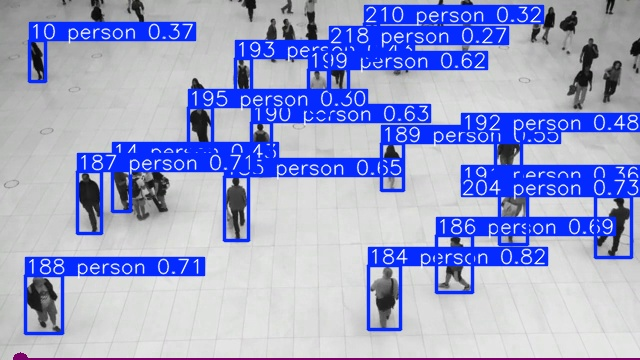


🎬 วิดีโอผลลัพธ์ (1.7 MB):



📂 ไฟล์ทั้งหมดใน Project Directory:
  📄 counting-result.avi (3.6 MB)
  📄 counting-result.mp4 (1.7 MB)
  📄 counting-sample.jpg (0.1 MB)
  📄 solutions-ci-demo.mp4 (0.3 MB)
  📄 yolo11n.pt (5.4 MB)


In [ ]:
from IPython.display import Image, HTML, display
from pathlib import Path
import base64

# --- 6.1 แสดงภาพ sample frame ---
sample_path = PROJECT_DIR / "counting-sample.jpg"
if sample_path.exists():
    print("🖼️ ภาพตัวอย่าง (Sample Frame):")
    display(Image(filename=str(sample_path), width=640))
else:
    print("⚠️ ไม่พบภาพตัวอย่าง - กรุณารัน Part 5 ก่อน")

# --- 6.2 แสดงวิดีโอผลลัพธ์ใน notebook ---
video_path = Path(OUTPUT_MP4)
if video_path.exists():
    print(f"\n🎬 วิดีโอผลลัพธ์ ({video_path.stat().st_size / (1024*1024):.1f} MB):")
    video_data = video_path.read_bytes()
    b64_video = base64.b64encode(video_data).decode("utf-8")
    display(HTML(f"""
    <video width=\"640\" controls autoplay muted loop>
        <source src=\"data:video/mp4;base64,{b64_video}\" type=\"video/mp4\">
        เบราว์เซอร์ไม่รองรับการเล่นวิดีโอ
    </video>
    """))
else:
    print("⚠️ ไม่พบวิดีโอผลลัพธ์ - กรุณารัน Part 5 ก่อน")

# --- 6.3 แสดงรายการไฟล์ ---
print(f"\n📂 ไฟล์ทั้งหมดใน Project Directory:")
for f in sorted(PROJECT_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {'📄' if f.is_file() else '📁'} {f.name} ({size_mb:.1f} MB)")

In [ ]:
# ประมวลผลวิดีโอ + เก็บ sample frame สำหรับแสดงผล
frame_count = 0
sample_frame = None

# Ensure the video capture is at the beginning
if not cap.isOpened():
    # Re-open if it somehow got closed, although it should be open from previous cell
    cap = cv2.VideoCapture(VIDEO_NAME)
    assert cap.isOpened(), "Error: ไม่สามารถเปิดวิดีโอได้! (re-opened in processing)"
cap.set(cv2.CAP_PROP_POS_FRAMES, 0) # Ensure it starts from the beginning

while cap.isOpened():
    success, im0 = cap.read()
    if not success:
        break
    results = counter(im0)
    plot_frame = results.plot_im
    video_writer.write(plot_frame)
    frame_count += 1

    # เก็บ frame ตรงกลางวิดีโอสำหรับแสดงผล
    if frame_count == total_frames // 2: # total_frames was 62, so this will be frame 31
        sample_frame = plot_frame.copy()

    if frame_count % 50 == 0:
        print(f"  ⏳ ประมวลผลแล้ว {frame_count}/{total_frames} frames...")

cap.release()
video_writer.release()

# บันทึก sample frame เป็นภาพบน Google Drive
SAMPLE_IMG = str(PROJECT_DIR / "counting-sample.jpg")
if sample_frame is not None:
    cv2.imwrite(SAMPLE_IMG, sample_frame)

print(f"\n✅ ประมวลผลเสร็จสิ้น! ({frame_count} frames)")
print(f"📁 วิดีโอผลลัพธ์: {OUTPUT_AVI}")
print(f"📁 ภาพตัวอย่าง: {SAMPLE_IMG}")

124: 360x640 1.0ms, 2 person
Speed: 189.1ms track, 1.0ms solution per image at shape (1, 3, 360, 640)

125: 360x640 2.4ms, 14 person
Speed: 159.3ms track, 2.4ms solution per image at shape (1, 3, 360, 640)

126: 360x640 3.6ms, 14 person
Speed: 156.4ms track, 3.6ms solution per image at shape (1, 3, 360, 640)

127: 360x640 3.7ms, 14 person
Speed: 153.9ms track, 3.7ms solution per image at shape (1, 3, 360, 640)

128: 360x640 3.4ms, 15 person
Speed: 151.0ms track, 3.4ms solution per image at shape (1, 3, 360, 640)

129: 360x640 3.5ms, 16 person
Speed: 150.4ms track, 3.5ms solution per image at shape (1, 3, 360, 640)

130: 360x640 4.0ms, 16 person
Speed: 158.4ms track, 4.0ms solution per image at shape (1, 3, 360, 640)

131: 360x640 3.6ms, 16 person
Speed: 163.5ms track, 3.6ms solution per image at shape (1, 3, 360, 640)

132: 360x640 3.6ms, 16 person
Speed: 152.4ms track, 3.6ms solution per image at shape (1, 3, 360, 640)

133: 360x640 4.1ms, 17 person
Speed: 155.5ms track, 4.1ms solutio

In [ ]:
# Convert AVI to MP4 for better compatibility
import subprocess

if Path(OUTPUT_AVI).exists():
    print(f"Converting {OUTPUT_AVI} to {OUTPUT_MP4}...")
    # Use ffmpeg via subprocess to convert. Assumes ffmpeg is available in Colab.
    # '-y' overwrites output file without asking
    # '-i' specifies input file
    # '-c:v' specifies video codec (libx264 is good for MP4)
    # '-pix_fmt yuv420p' ensures compatibility
    command = [
        "ffmpeg",
        "-y",
        "-i", str(OUTPUT_AVI),
        "-c:v", "libx264",
        "-pix_fmt", "yuv420p",
        str(OUTPUT_MP4)
    ]
    try:
        subprocess.run(command, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        print(f"✅ Conversion successful to {OUTPUT_MP4}")
    except subprocess.CalledProcessError as e:
        print(f"❌ Error during conversion: {e}")
        print(f"Stderr: {e.stderr.decode()}")
else:
    print(f"⚠️ {OUTPUT_AVI} not found for conversion.")

Converting /content/drive/MyDrive/YOLO_Labs/object_counting/counting-result.avi to /content/drive/MyDrive/YOLO_Labs/object_counting/counting-result.mp4...
✅ Conversion successful to /content/drive/MyDrive/YOLO_Labs/object_counting/counting-result.mp4


🖼️ ภาพตัวอย่าง (Sample Frame):


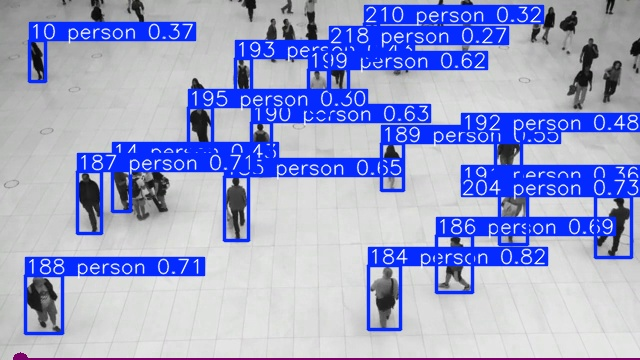


🎬 วิดีโอผลลัพธ์ (0.3 MB):



📂 ไฟล์ทั้งหมดใน Project Directory:
  📄 counting-result.avi (3.6 MB)
  📄 counting-result.mp4 (0.3 MB)
  📄 counting-sample.jpg (0.1 MB)
  📄 solutions-ci-demo.mp4 (0.3 MB)
  📄 yolo11n.pt (5.4 MB)


In [ ]:
from IPython.display import Image, HTML, display
from pathlib import Path
import base64

# --- 6.1 แสดงภาพ sample frame ---
sample_path = PROJECT_DIR / "counting-sample.jpg"
if sample_path.exists():
    print("🖼️ ภาพตัวอย่าง (Sample Frame):")
    display(Image(filename=str(sample_path), width=640))
else:
    print("⚠️ ไม่พบภาพตัวอย่าง - กรุณารัน Part 5 ก่อน")

# --- 6.2 แสดงวิดีโอผลลัพธ์ใน notebook ---
video_path = Path(OUTPUT_MP4)
if video_path.exists():
    print(f"\n🎬 วิดีโอผลลัพธ์ ({video_path.stat().st_size / (1024*1024):.1f} MB):")
    video_data = video_path.read_bytes()
    b64_video = base64.b64encode(video_data).decode("utf-8")
    display(HTML(f"""
    <video width=\"640\" controls autoplay muted loop>
        <source src=\"data:video/mp4;base64,{b64_video}\" type=\"video/mp4\">
        เบราว์เซอร์ไม่รองรับการเล่นวิดีโอ
    </video>
    """))
else:
    print("⚠️ ไม่พบวิดีโอผลลัพธ์ - กรุณารัน Part 5 ก่อน")

# --- 6.3 แสดงรายการไฟล์ ---
print(f"\n📂 ไฟล์ทั้งหมดใน Project Directory:")
for f in sorted(PROJECT_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {'📄' if f.is_file() else '📁'} {f.name} ({size_mb:.1f} MB)")

---
## 📝 สรุป (Summary)

| หัวข้อ | รายละเอียด |
|--------|-----------|
| **โมเดล** | YOLO11n (เสถียร, เบา) |
| **Task** | Object Counting - นับวัตถุที่ผ่านพื้นที่ |
| **Input** | วิดีโอ / RTSP Stream |
| **Output** | วิดีโอ + ภาพตัวอย่าง บน Google Drive |
| **Project Dir** | `/content/drive/MyDrive/YOLO_Labs/object_counting/` |

### 🧪 ลองทำเพิ่มเติม:
1. ลองเปลี่ยน `region_points` เป็น 2 จุดสำหรับนับแบบเส้น: `[(20, 400), (1080, 400)]`
2. เพิ่ม `classes=[0, 2]` ใน ObjectCounter เพื่อนับเฉพาะคนและรถยนต์
3. ลองใช้โมเดล `yolo11s.pt` แล้วเปรียบเทียบ

---
Crafted with 💙 by [Ultralytics](https://ultralytics.com/)